# Task 02 – Graph Representation and Analysis

**Course Module:** CCS4354 – Tensors and Graphs  
**Dataset:** `ogbn-arxiv` Citation Network (Open Graph Benchmark)  

---
### Required Deliverables & Analysis Covered:
1. **Graph Representation as an Edge List:** Convert PyG `edge_index` to source $\to$ target directed citation pairs.
2. **Node Feature Description:** Detailed inspection of the 128-dimensional Word2Vec continuous feature vectors.
3. **Graph Structural Analysis:**
   - **Degree Distribution:** In-degree, out-degree, and total degree metrics (Min, Max, Mean, Median).
   - **Graph Density:** Formal density calculation $\rho = \frac{|E|}{|V|(|V|-1)}$.
   - **Connected Component Analysis:** Weakly and strongly connected component counts and largest component size.
4. **Sample Subgraph Visualization:** 2D topological layout of a local citation ego-network.

In [1]:
import sys
from pathlib import Path

# Make the project root importable when running locally
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import RAW_DATA_DIR, RESULTS_DIR
from src.data import load_ogbn_arxiv
from src.graph.graph_analysis import graph_summary
from src.graph.components import connected_component_summary
from src.graph.visualization import plot_sample_subgraph

out_dir = RESULTS_DIR / 'graph_analysis'
out_dir.mkdir(parents=True, exist_ok=True)

print("📥 Loading OGBN-Arxiv Graph Dataset...")
dataset, data, split_idx = load_ogbn_arxiv(RAW_DATA_DIR)
print(f"✅ Successfully loaded: {data.num_nodes:,} nodes, {data.num_edges:,} edges.")

📥 Loading OGBN-Arxiv Graph Dataset...


✅ Successfully loaded: 169,343 nodes, 2,315,598 edges.


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


---
## 1. Graph Representation as an Edge List

The citation network is stored as a directed PyTorch tensor $\mathbf{E} \in \mathbb{Z}^{2 \times |E|}$ (`edge_index`), where row 0 contains the **Source Paper IDs** (citing papers) and row 1 contains the **Target Paper IDs** (cited papers).

In [2]:
# Convert PyG edge_index to a tabular Edge List
src_nodes = data.edge_index[0].cpu().numpy()
dst_nodes = data.edge_index[1].cpu().numpy()

edge_list_df = pd.DataFrame({
    'Source_Paper_ID (Citing)': src_nodes,
    'Target_Paper_ID (Cited)': dst_nodes
})

# Export sample edge list (first 1000 edges)
edge_list_df.head(1000).to_csv(out_dir / 'sample_edge_list.csv', index=False)

print("📄 Sample Edge List (First 10 Citation Links):")
display(edge_list_df.head(10))
print(f"Total Citation Edges in Graph: {len(edge_list_df):,}")

📄 Sample Edge List (First 10 Citation Links):


,Source_Paper_ID (Citing),Target_Paper_ID (Cited)
0,0,411
1,0,640
2,0,1162
3,0,1897
4,0,3396
5,0,3787
6,0,4692
7,0,5037
8,0,5537
9,0,5611


Total Citation Edges in Graph: 2,315,598


---
## 2. Node Features Description

- **Feature Matrix Shape:** $169,343 \times 128$
- **Feature Origin:** 128-dimensional dense continuous embeddings generated by averaging the **Word2Vec skip-gram** embeddings of words in each paper's title and abstract from the Microsoft Academic Graph (MAG).
- **Properties:** Dense, real-valued continuous semantic vectors capturing domain terminology across 40 computer science categories.

In [3]:
feat_matrix = data.x.cpu().numpy()

feat_stats = pd.DataFrame({
    'Metric': ['Node Count', 'Feature Dimension', 'Mean Value', 'Std Dev', 'Min Value', 'Max Value', 'Sparsity (% zeros)'],
    'Value': [
        f"{feat_matrix.shape[0]:,}",
        f"{feat_matrix.shape[1]}",
        f"{feat_matrix.mean():.4f}",
        f"{feat_matrix.std():.4f}",
        f"{feat_matrix.min():.4f}",
        f"{feat_matrix.max():.4f}",
        f"{(feat_matrix == 0).mean() * 100:.2f}%"
    ]
})

print("🔬 Node Feature Statistics:")
display(feat_stats)

print("\nPreview of Node 0 (First 10 Embedding Dimensions):")
print(data.x[0][:10].tolist())

🔬 Node Feature Statistics:


,Metric,Value
0,Node Count,"169,343"
1,Feature Dimension,128
2,Mean Value,0.0205
3,Std Dev,0.2332
4,Min Value,-1.3889
5,Max Value,1.6387
6,Sparsity (% zeros),0.00%



Preview of Node 0 (First 10 Embedding Dimensions):
[-0.05794300138950348, -0.05253000184893608, -0.0726030021905899, -0.026554999873042107, 0.1304350048303604, -0.24138599634170532, -0.4492419958114624, -0.018442999571561813, -0.08721800148487091, 0.11231999844312668]


---
## 3. Graph Structural Analysis (Degree, Density & Connected Components)

### Mathematical Definitions:
1. **Graph Density ($\rho$):**
   $$\rho = \frac{|E|}{|V|(|V|-1)} = \frac{2,315,598}{169,343 \times 169,342} \approx 1.615 \times 10^{-4}$$
2. **Connected Components:**
   Measures graph fragmentation and ensures the presence of a giant connected component spanning the citation manifold.

In [4]:
# Overall Graph Metrics
summary = graph_summary(data)
pd.DataFrame([summary]).to_csv(out_dir / 'graph_summary.csv', index=False)
(out_dir / 'graph_density.txt').write_text(f"Graph density: {summary['density']:.8f}\n")

# Connected Component Analysis
print("🔍 Analyzing Connected Components...")
comp_summary = connected_component_summary(data, max_nodes=50000)

struct_df = pd.DataFrame({
    'Property': ['Total Nodes (|V|)', 'Total Edges (|E|)', 'Graph Density (ρ)', 'Min Degree', 'Max Degree', 'Mean Degree', 'Median Degree', 'Sampled Component Count', 'Largest Component Size'],
    'Value': [
        f"{summary['nodes']:,}",
        f"{summary['edges']:,}",
        f"{summary['density']:.8f}",
        f"{summary['min_degree']:.0f}",
        f"{summary['max_degree']:.0f}",
        f"{summary['mean_degree']:.2f}",
        f"{summary['median_degree']:.0f}",
        f"{comp_summary['component_count']:,}",
        f"{comp_summary['largest_component_size']:,}"
    ]
})

display(struct_df)

🔍 Analyzing Connected Components...


,Property,Value
0,Total Nodes (|V|),"169,343"
1,Total Edges (|E|),"2,315,598"
2,Graph Density (ρ),0.00016150
3,Min Degree,1
4,Max Degree,13161
5,Mean Degree,13.67
6,Median Degree,6
7,Sampled Component Count,"12,613"
8,Largest Component Size,"33,831"


---
## 4. Degree Distribution & Subgraph Visualizations

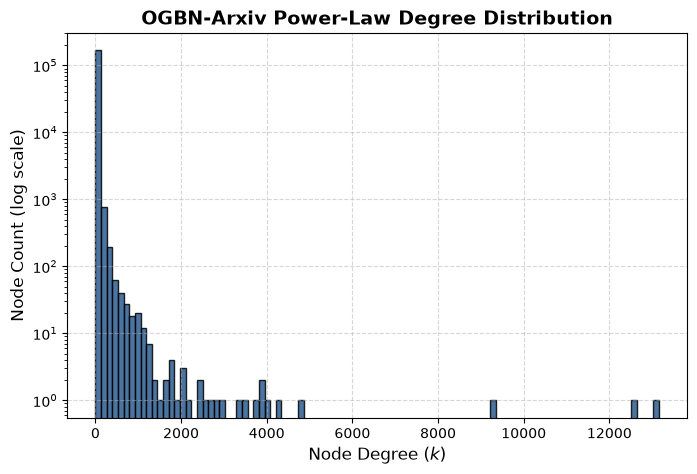

🎨 Rendering Sample Citation Ego Subgraph...


✅ Visualizations successfully generated in: D:\Projects\Done\Tenso Project\results\graph_analysis


In [5]:
# Plot Degree Distribution on Log-Scale
degrees = data.edge_index[0].bincount(minlength=data.num_nodes).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=100, log=True, color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.xlabel('Node Degree ($k$)', fontsize=12)
plt.ylabel('Node Count (log scale)', fontsize=12)
plt.title('OGBN-Arxiv Power-Law Degree Distribution', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(out_dir / 'degree_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

# Render Sample Subgraph
print("🎨 Rendering Sample Citation Ego Subgraph...")
plot_sample_subgraph(data, out_dir / 'sample_subgraph.png', center_node=0, hops=2)
print(f"✅ Visualizations successfully generated in: {out_dir}")